In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data_path = '../data/raw/WineQT.csv'
df = pd.read_csv(data_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


### Análisis de las Colas: Kurtosis

In [5]:
kurtosis_values = df.kurtosis().sort_values(ascending=False)
print(f"Kurtosis asociada a los valores del Dataset:\n{kurtosis_values}")

Kurtosis asociada a los valores del Dataset:
chlorides               47.078324
residual sugar          27.675366
sulphates               12.017377
total sulfur dioxide     5.098748
free sulfur dioxide      1.932170
fixed acidity            1.384614
volatile acidity         1.375531
pH                       0.925791
density                  0.888123
quality                  0.314664
alcohol                  0.221179
citric acid             -0.714686
Id                      -1.216364
dtype: float64


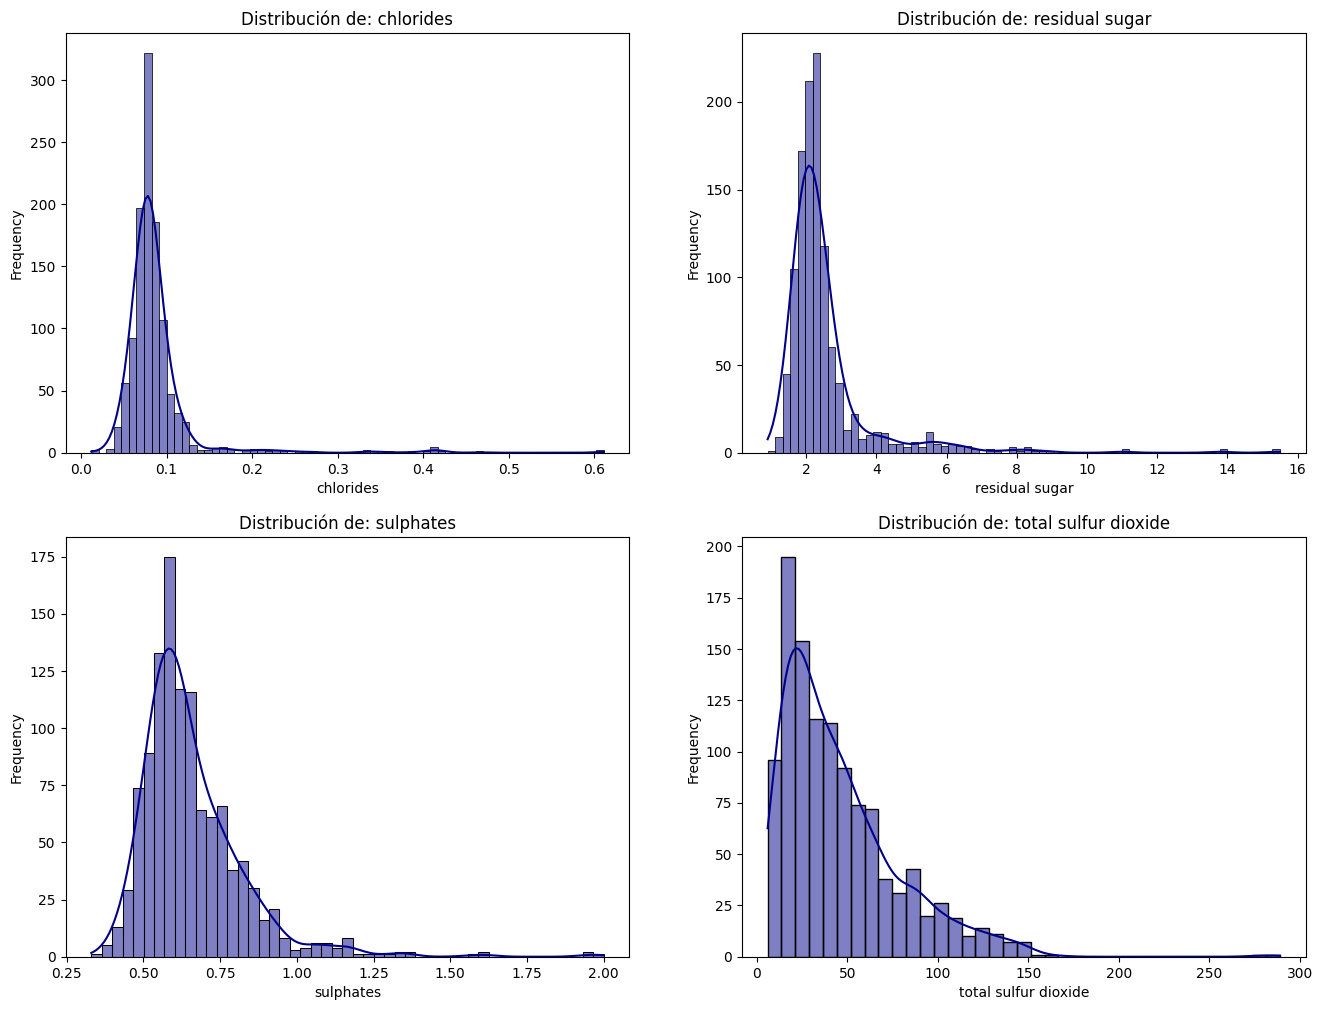

In [15]:
leptokurtic_vars = ["chlorides", "residual sugar", "sulphates", "total sulfur dioxide"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# Con KDE muestro la Curva de Densidad
for idx, var in enumerate(leptokurtic_vars):
    sns.histplot(df[var], kde=True, ax=axes[idx], color="darkblue")
    axes[idx].set_title(f"Distribución de: {var}")
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel("Frequency")

In [20]:
normal_chlorides = df[df['chlorides'] < 0.4]
high_chlorides = df[df['chlorides'] >= 0.4]
print("Calidad promedio de vinos muy salados:", high_chlorides['quality'].mean())
print("Calidad promedio de todo el dataset:", normal_chlorides['quality'].mean())

Calidad promedio de vinos muy salados: 5.1
Calidad promedio de todo el dataset: 5.661959399823478


### HeatMap de Spearman: Check de Multicolinealidad

Text(0.5, 1.0, 'Spearman Heatmap')

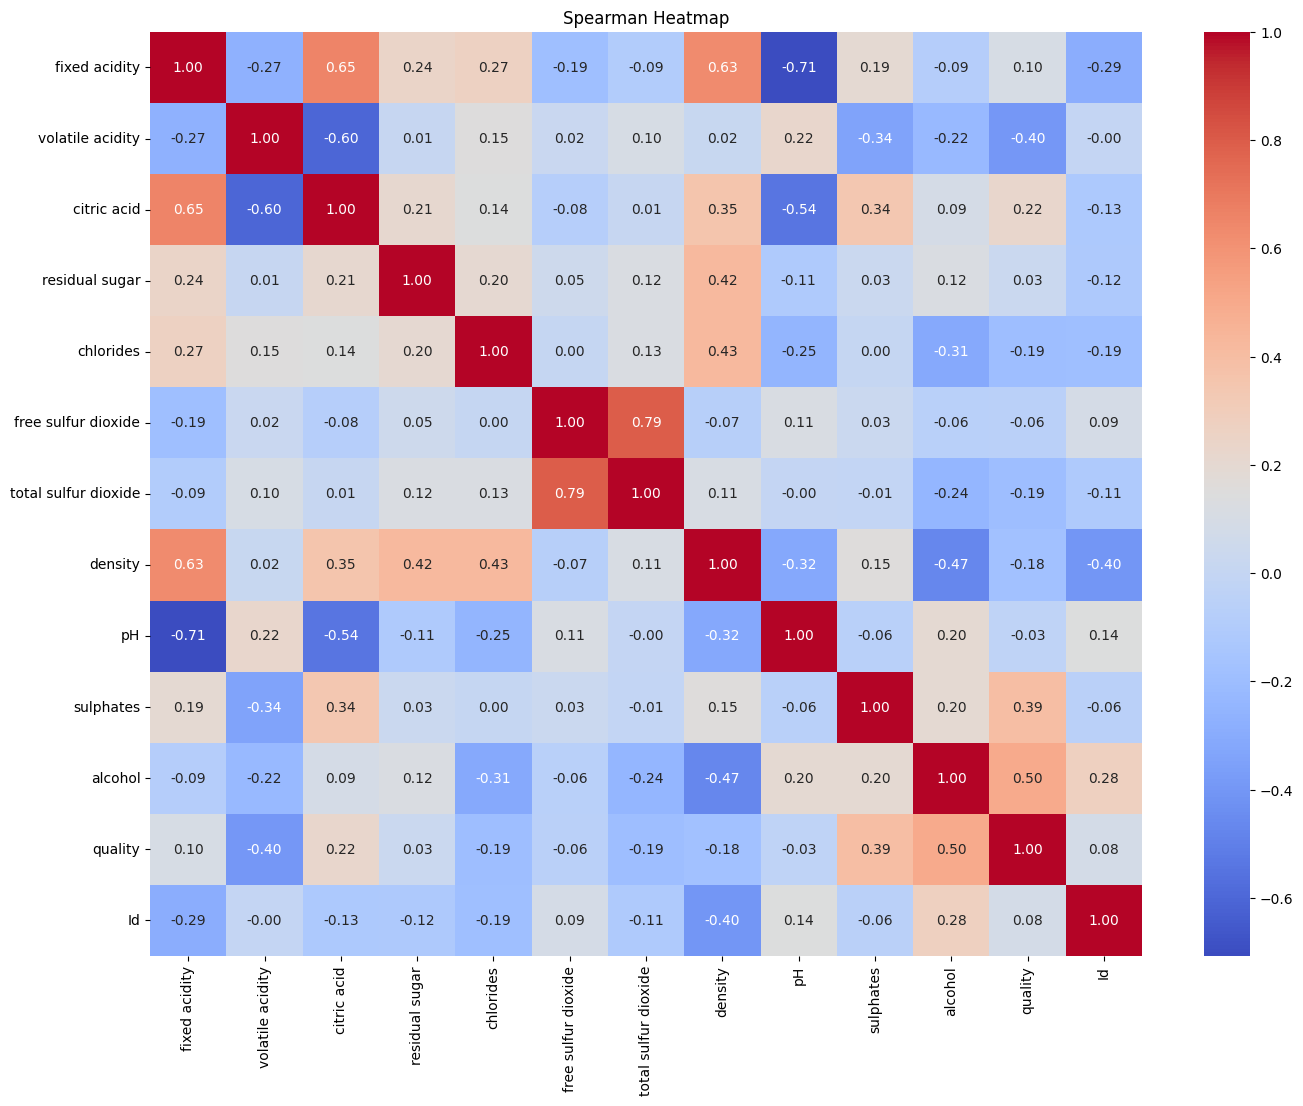

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(method="spearman"), annot=True, fmt='.2f', cmap="coolwarm")
plt.title("Spearman Heatmap")

Tras aplicar Via Negativa elimino: PH, Fixed Acidity, Free Sulfur Dioxide, Id

### BoxPlots

In [27]:
relevant_variables = ["chlorides", "residual sugar", "sulphates"
                      ,"total sulfur dioxide", "volatile acidity", "density"
                      ,"quality", "alcohol", "citric acid"]
filtered_df = df[relevant_variables].copy()
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   chlorides             1143 non-null   float64
 1   residual sugar        1143 non-null   float64
 2   sulphates             1143 non-null   float64
 3   total sulfur dioxide  1143 non-null   float64
 4   volatile acidity      1143 non-null   float64
 5   density               1143 non-null   float64
 6   quality               1143 non-null   int64  
 7   alcohol               1143 non-null   float64
 8   citric acid           1143 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 80.5 KB


C:\Users\aleja\AppData\Local\Temp\ipykernel_13068\341304404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=var, data=filtered_df, ax=axes[idx], palette="Set2")
C:\Users\aleja\AppData\Local\Temp\ipykernel_13068\341304404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=var, data=filtered_df, ax=axes[idx], palette="Set2")
C:\Users\aleja\AppData\Local\Temp\ipykernel_13068\341304404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=var, data=filtered_df, ax=axes[idx], palette="Set2")
C:\User

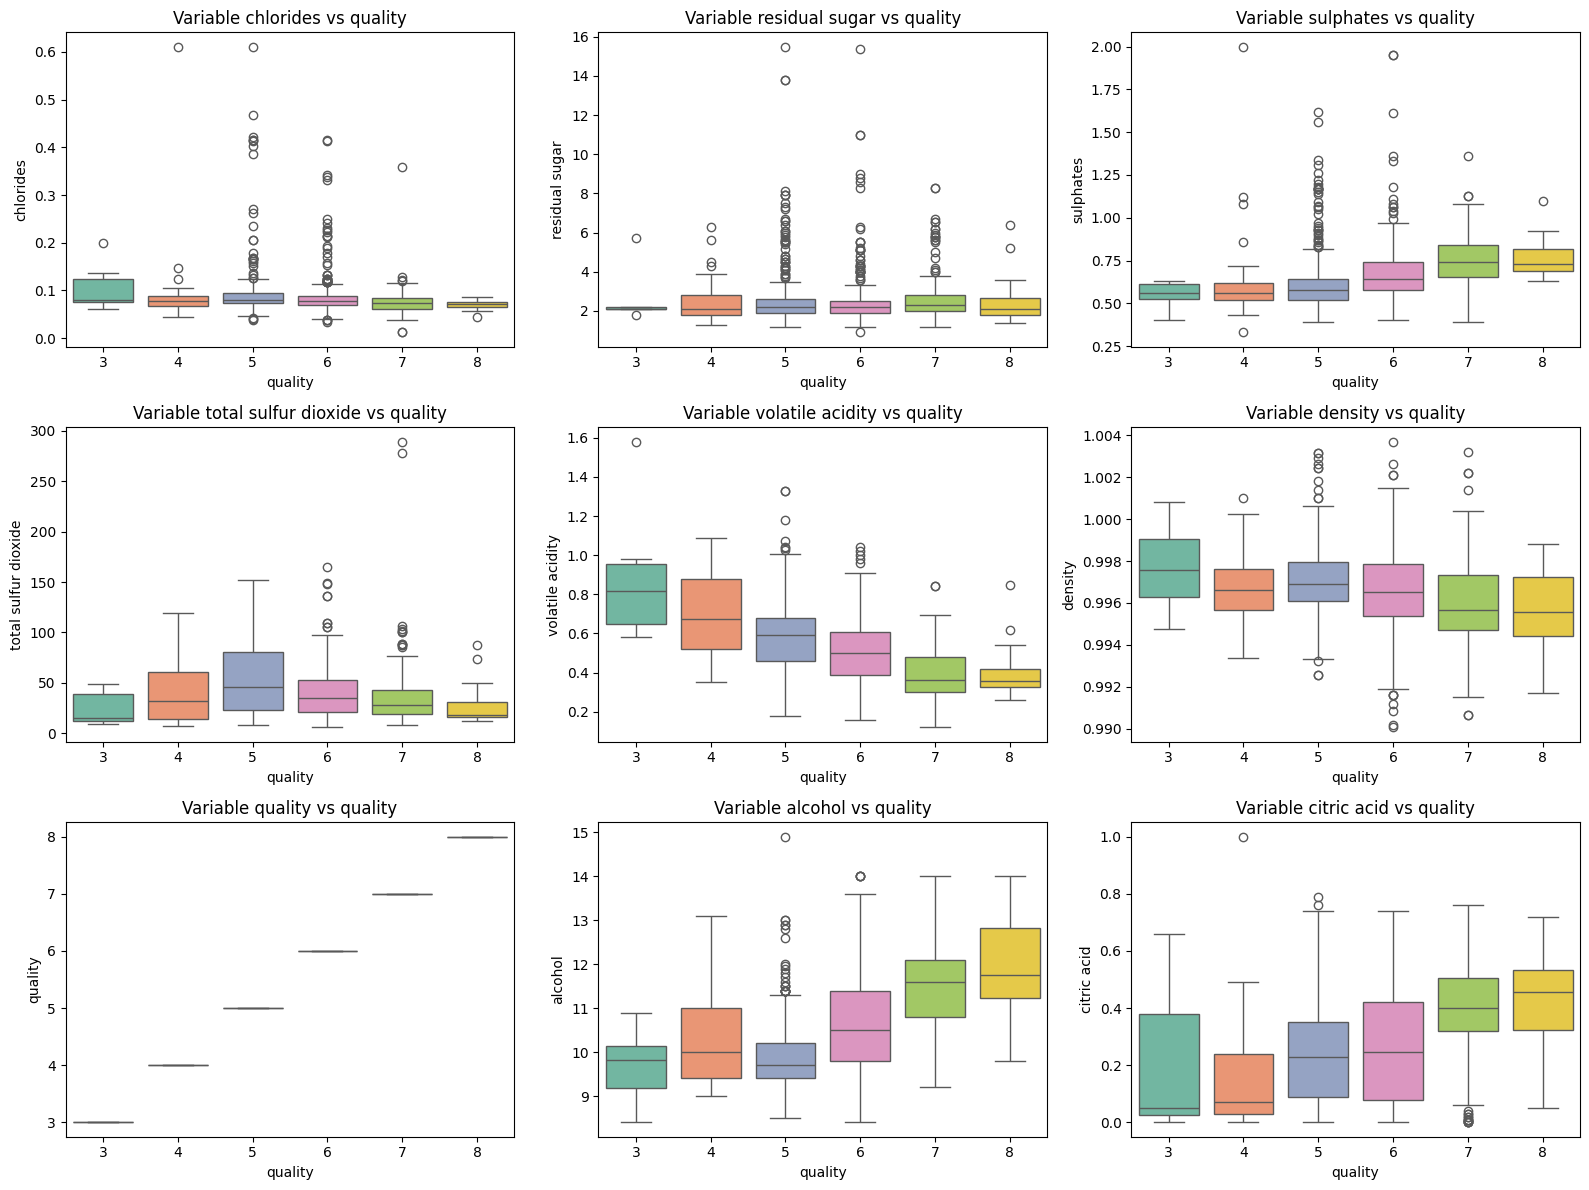

In [35]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()
for idx, var in enumerate(filtered_df.columns):
    sns.boxplot(x="quality", y=var, data=filtered_df, ax=axes[idx], palette="Set2")
    axes[idx].set_title(f"Variable {var} vs quality")
plt.tight_layout()